# Семинар 9


# Метод тяжёлого шарика. Ускоренный градиентный метод

# Метод сопряжённых градиентов (Conjugate gradient method)


In [1]:
import matplotlib.pyplot as plt
import ipywidgets as ipywidg
from methods import GradientDescent, parse_logs
from step_size import *
import numpy as np

plt.rc("text", usetex=True)

%matplotlib notebook

In [2]:
import jax
import jax.numpy as jnp

In [7]:
import matplotlib

matplotlib.use("Agg")
params = {
    "legend.fontsize": 35,
    "legend.handlelength": 4,
    "axes.labelsize": 60,
    "xtick.labelsize": 35,
    "ytick.labelsize": 35,
    "lines.linewidth": 7,
    "axes.titlesize": 30,
}
matplotlib.rcParams.update(params)

## 1. Метод тяжёлого шарика (Б.Т. Поляк, 1964)

- Для квадратичной целевой функции зигзагообразное поведение градиентного спуска обусловлено неоднородностью направлений
- Учитывать предыдущие направления для поиска новой точки
- Метод тяжёлого шарика
$$
x_{k+1} = x_k - \alpha_k f'(x_k) + {\color{red}{\beta_k(x_k - x_{k-1})}}
$$

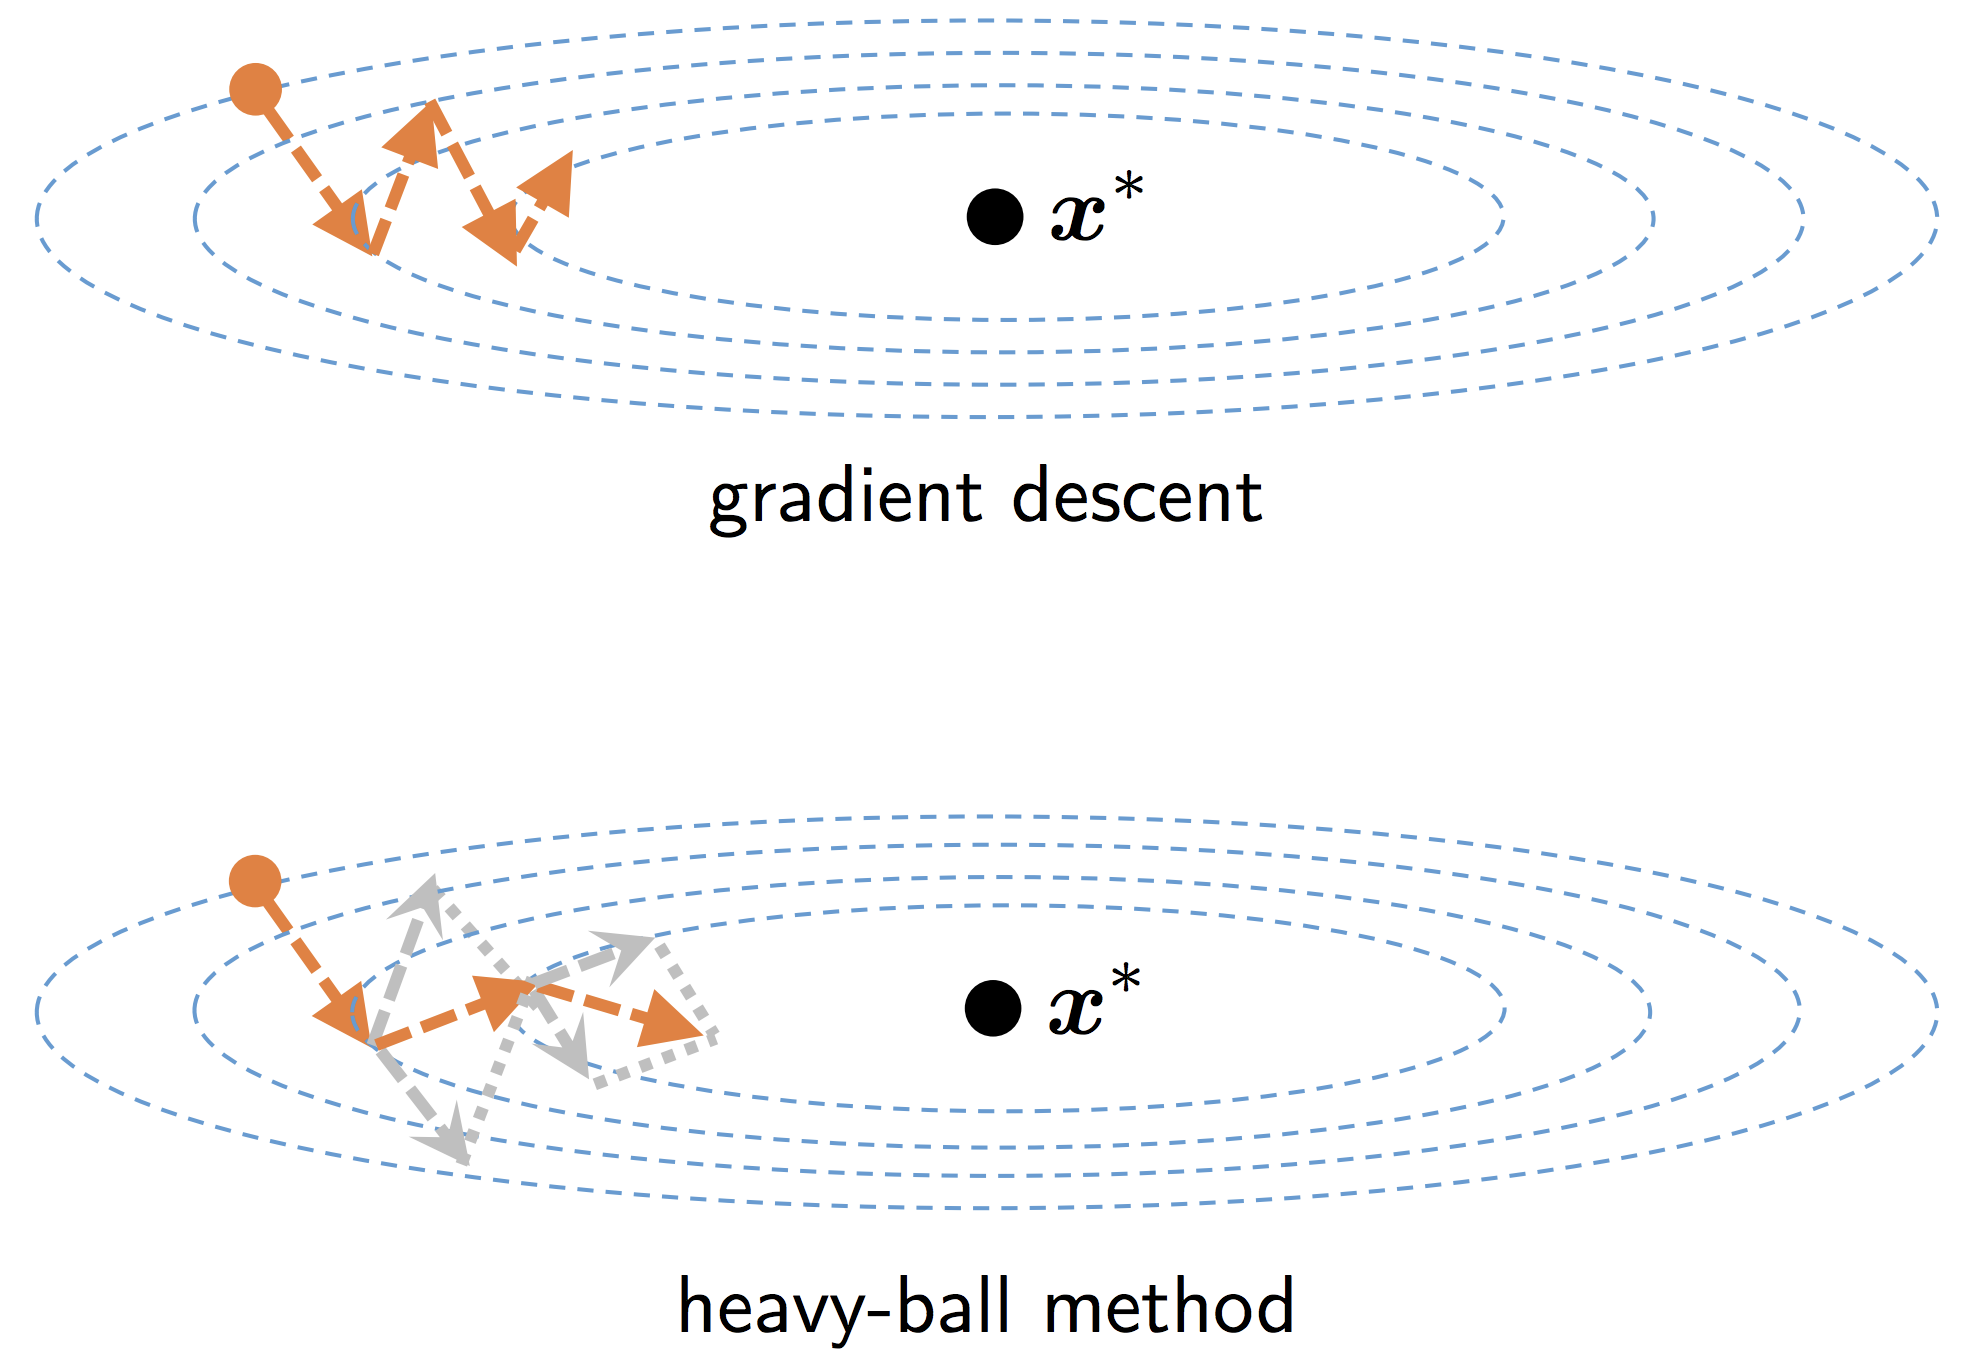

In [8]:
from IPython.display import Image
Image(filename='heavy_ball.png')

$L \sim \mu: \alpha_k\sim 1/L\sim 1/\mu, \beta_k\sim 0$

$L \gg \mu: \alpha_k\sim 4/L, \beta_k \sim 1$

### 1.1. Сходимость

Пусть $f$ сильно выпукла с Липшицевым градиентом. Тогда для $\alpha_k = \frac{4}{(\sqrt{L} + \sqrt{\mu})^2}$ и $\beta_k = \max(|1 - \sqrt{\alpha_k L}|^2, |1 - \sqrt{\alpha_k \mu}|^2)$ справедлива следующая оценка сходимости

$$ 
\left\| \begin{bmatrix} x_{k+1} - x^* \\ x_k - x^* \end{bmatrix} \right\|_2
\leq 
\left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \left \|
\begin{bmatrix} x_1 - x^* \\ x_0 - x^* \end{bmatrix}
\right \|_2
$$

где $\kappa = \frac{L}{\mu}$

In [9]:
def q_no_acc(kappa):
    return (kappa - 1) / (kappa + 1)


def q_acc(kappa):
    return (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)


q_no_acc(1000) ** 100

0.8187306984958972

In [6]:
q_acc(1000)**100

0.0017879871818238682

In [7]:
class HeavyBall:
    def __init__(self, alpha=None, beta=None, L=None, mu=None, 
                 return_history=True, name=None):
        self.name = name
        if alpha is not None and beta is not None:
            self.alpha = alpha
            self.beta = beta
        else:
            self.alpha, self.beta = self.get_alpha_beta(L, mu)
        self.return_history = return_history
        self.history = []
    
    @staticmethod
    def get_alpha_beta(L, mu):
        alpha = 4 / (np.sqrt(L) + np.sqrt(mu))**2
        beta1 = (1 - np.sqrt(alpha * L))**2
        beta2 = (1 - np.sqrt(alpha * mu))**2
        beta = max(beta1, beta2)
        return alpha, beta
        
    
    def __call__(self, x0, f, gradf, N):
        self.history = [(x0, time.time())]
        alpha, beta = self.alpha, self.beta
        x = x0.copy()
        x_prev = x0.copy()
        for k in range(N):
            g = gradf(x)
            x_prev, x = x, x - alpha * g + beta * (x - x_prev)
            if self.return_history:
                self.history.append((x, time.time()))
        return x
    
    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        alpha, beta = self.alpha, self.beta
        x = x0.copy()
        k = 0
        x_prev = x0.copy()
        while k == 0 or np.linalg.norm(gradf(x)) > tol: 
            g = gradf(x)
            x_prev, x = x, x - alpha * g + beta * (x - x_prev)
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

### 1.2. Эксперименты

#### Зависимость от обусловленности матрицы $f''(x)$
Рассмотрим задачу 
$$
\min f(x),
$$ 
где
$$ f(x) = x^{\top}Ax, \; A = \begin{bmatrix} 1 & 0\\ 0 & \gamma \end{bmatrix} $$

$$
f'(x) = 2Ax
$$

In [8]:
def my_f(x, A):
    return 0.5 * x.dot(A.dot(x))

def my_gradf(x, A):
    return A.dot(x)

In [ ]:
n = 2
x0 = np.zeros(n) + 1
gammas = []
gd_iters = []
hb_iters = []
for i in range(-4, 5):
    gamma = 10**i
    A = np.diag([gamma, 1])
    gammas.append(gamma)
    L = max(1, gamma)
    mu = min(1, gamma)

    def f(x):
        return 1 / 2 * x.T @ A @ x

    def gradf(x):
        return A @ x

    method = GradientDescent(ConstantStepSize(1 / L), name="GD")
    method.solve(
        x0,
        f,
        gradf,
        tol=1e-9,
        max_iter=int(1e5),
    )
    gd_iters.append(len(method.history))

    method = HeavyBall(L=L, mu=mu, name="HB")

    def f(x):
        return 1 / 2 * x.T @ A @ x

    def gradf(x):
        return A @ x

    method.solve(x0, f, gradf, tol=1e-9)
    hb_iters.append(len(method.history))

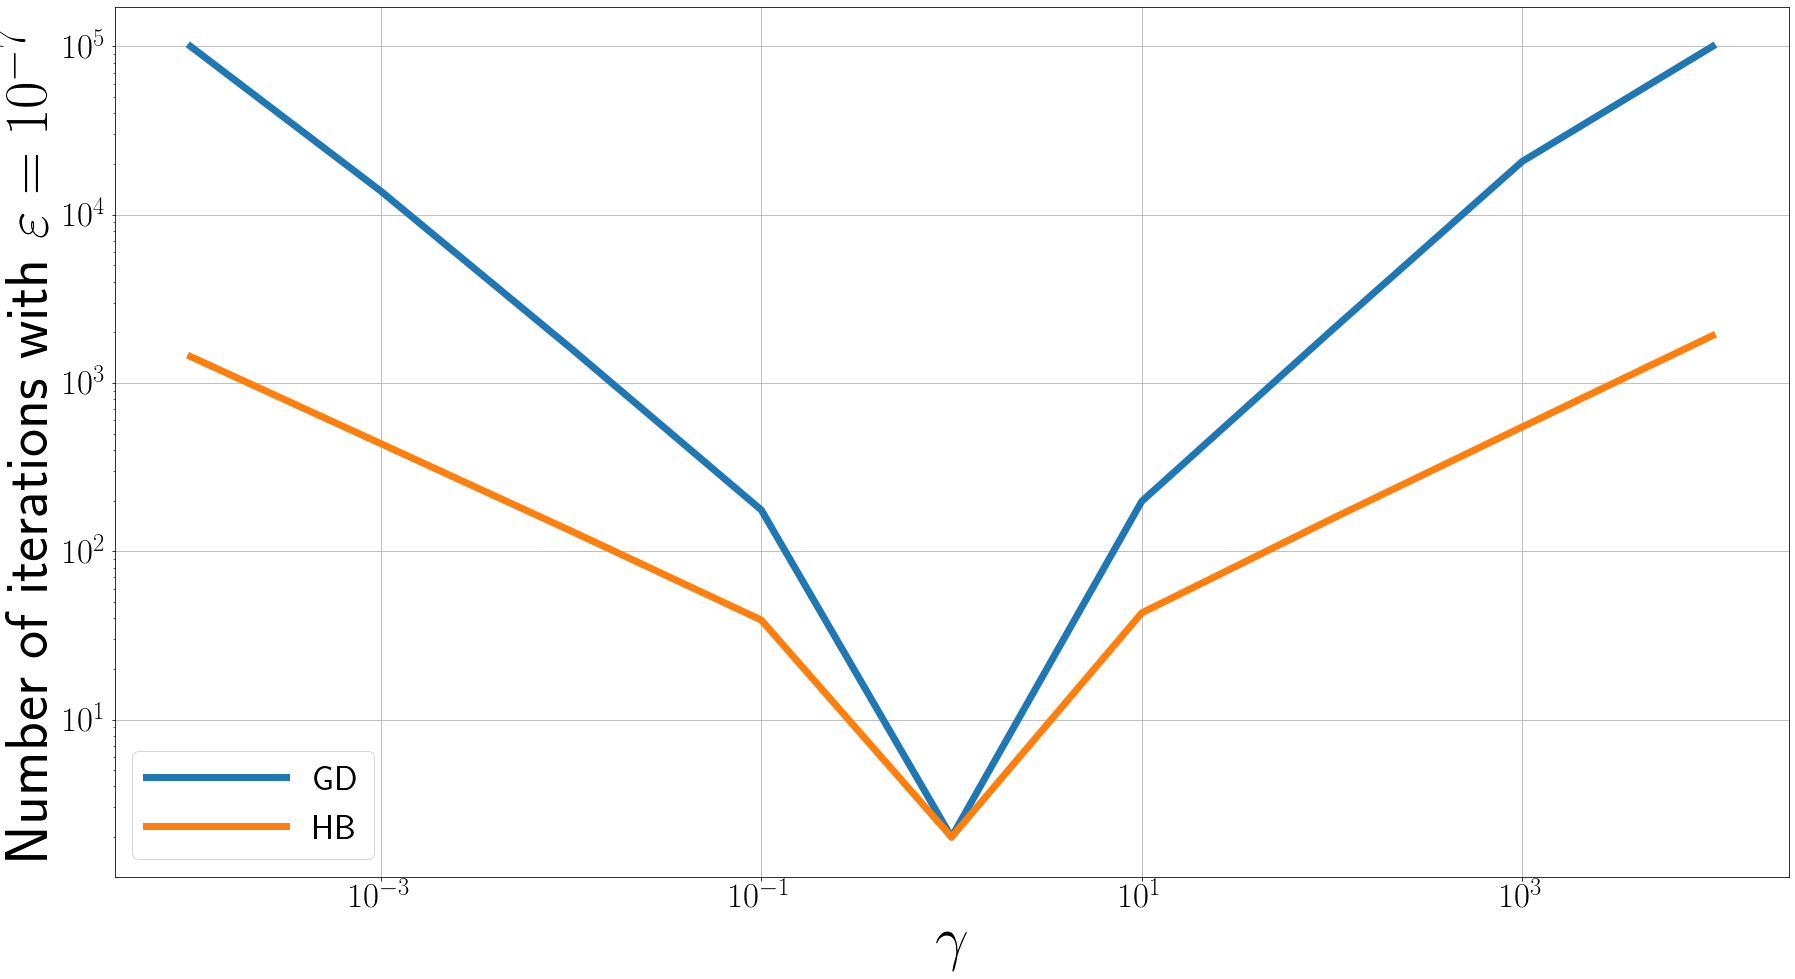

In [10]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(30, 16))
plt.loglog(gammas, gd_iters, label="GD")
plt.loglog(gammas, hb_iters, label="HB")
plt.legend()
plt.grid()
plt.xlabel(r"$\gamma$")
plt.ylabel(r"Number of iterations with $\varepsilon = 10^{-7}$")
plt.legend()

#### Тестовая функция

$$
f(x) = \frac{1}{2}x^{\top}Ax - b^{\top}x \to \min_x
$$

In [ ]:
np.random.seed(1)
n = 50
A = np.random.randn(n, n)
A = A.T @ A
# gamma = 1e-3
# A = np.diag([gamma, 1])
b = np.random.randn(n)


def f(x):
    return 1 / 2 * x.T @ A @ x + b.T @ x


def gradf(x):
    return A @ x + b


x0 = np.zeros(n) + 10

In [12]:
A_eigvals = np.linalg.eigvalsh(A)
L = np.max(A_eigvals)
mu = np.min(A_eigvals)
L/mu

14055.656099228476

In [13]:
method = HeavyBall(L=L, mu=mu, name="HB optimal")
method.alpha, method.beta

(0.019911680638229377, 0.9668228720824766)

In [ ]:
methods = [
    GradientDescent(ConstantStepSize(1 / L), name="GD, 1/L"),
    HeavyBall(L=L, mu=mu, name="HB optimal"),
    GradientDescent(Armijo(rho=1 / 2), name=r"GD, Armijo"),
    HeavyBall(alpha=0.019, beta=0.95, name="HB"),
]

In [15]:
N = 1500
for method in methods:
    method(x0, f, gradf, N)

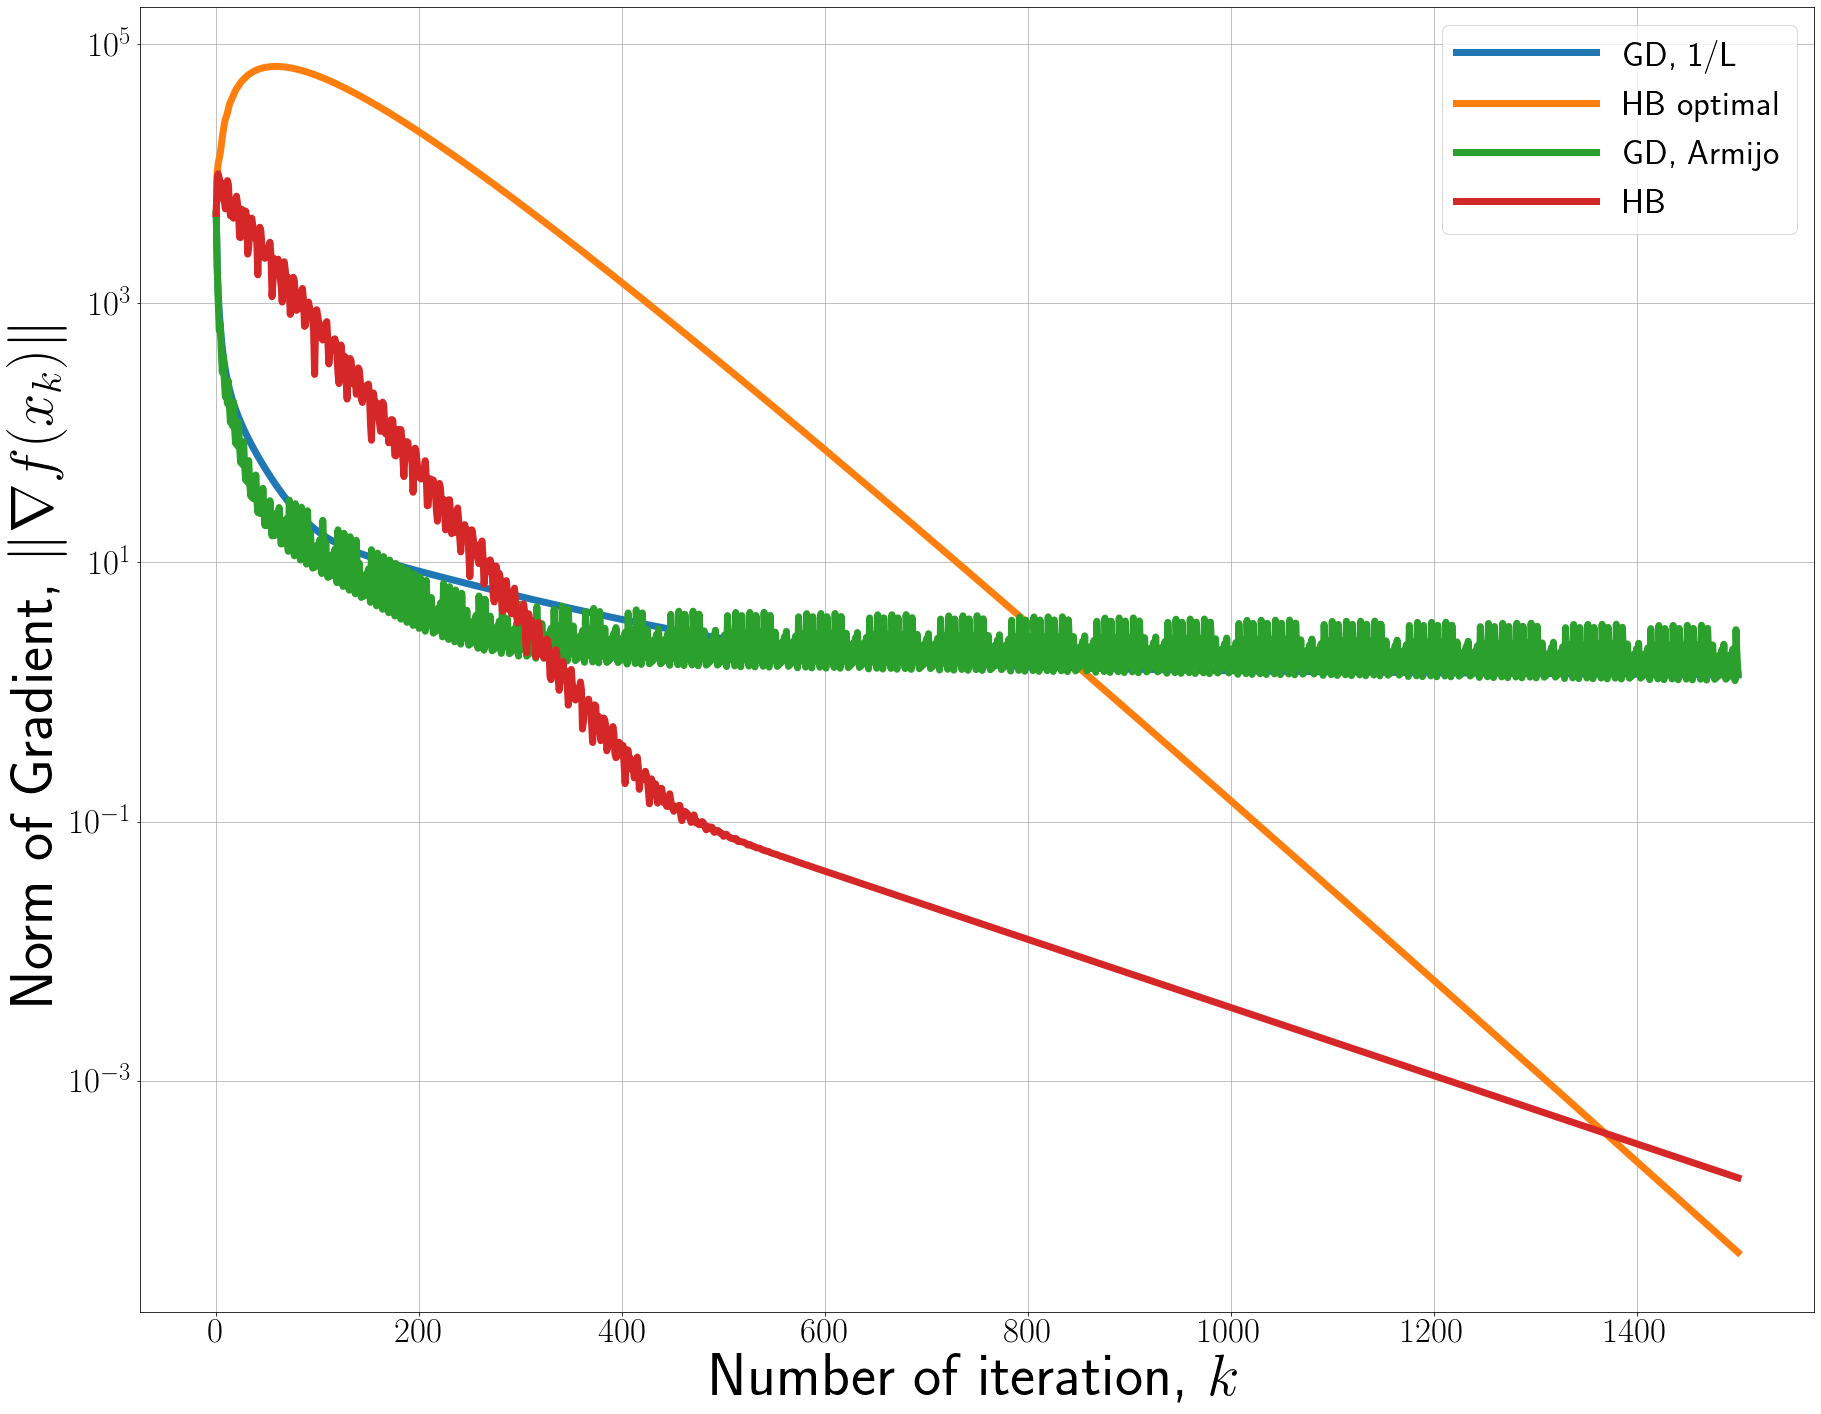

In [ ]:
%matplotlib inline
plt.figure(figsize=(30, 24))


def funcx(x):
    return np.linalg.norm(gradf(x))


for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

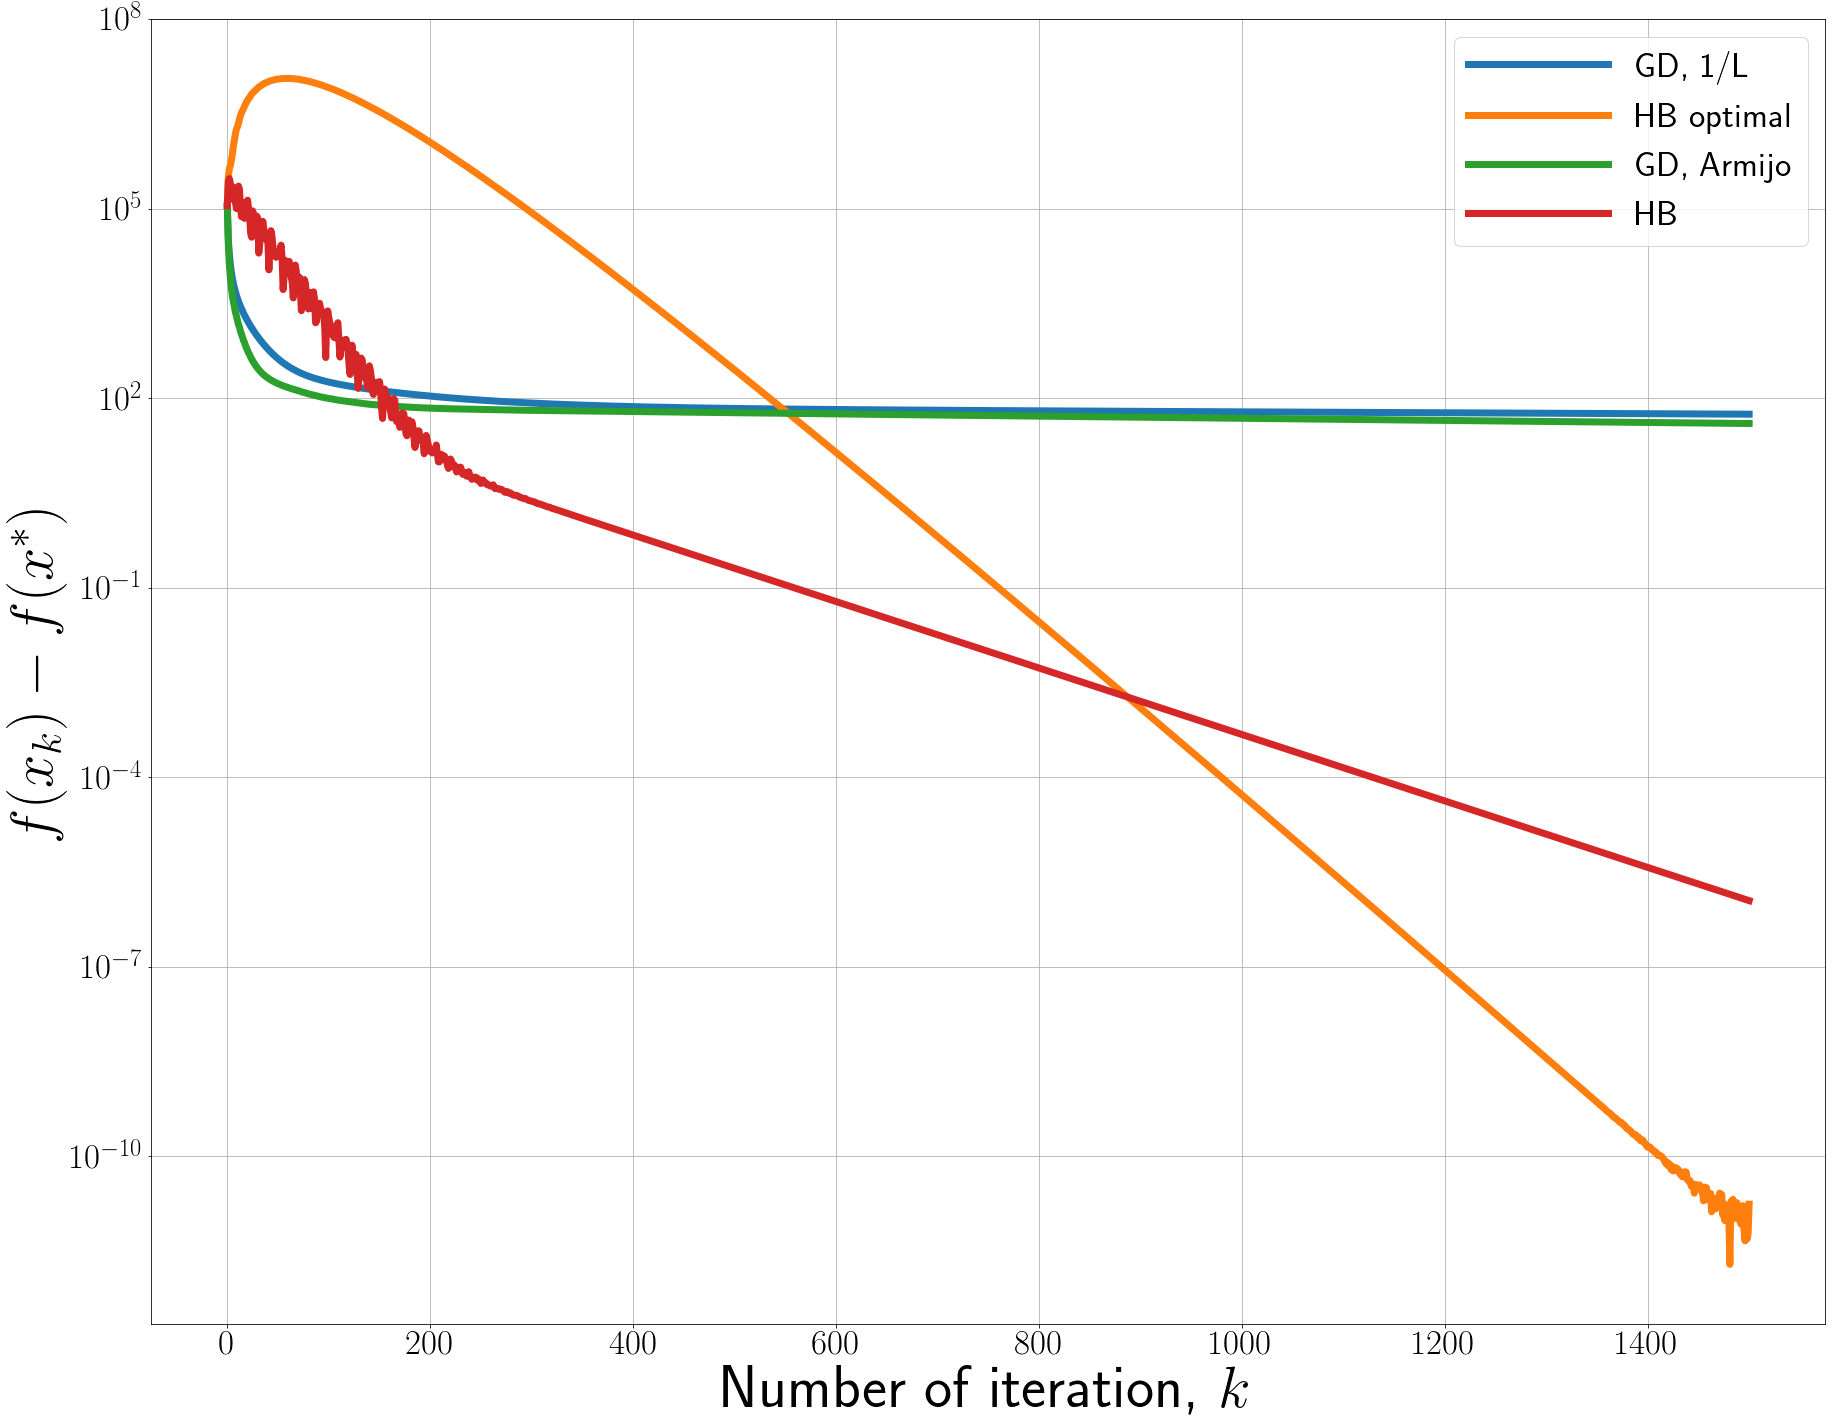

In [17]:
%matplotlib inline
plt.figure(figsize=(30, 24))
f_star = f(np.linalg.solve(A, -b))
funcx = lambda x: f(x) - f_star
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"$f(x_k)-f(x^*)$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

#### Главное про метод тяжёлого шарика

- Двухшаговый метод
- Не обязательно монотонный
- Параметры зависят от неизвестных констант
- Решает проблему осцилляций для плохо обусловленных задач
- Сходимость для сильно выпуклых фукнкций сопадает с оптимальным порядком

## 2. Ускоренный метод Нестерова

Одна из возможных форм записи 
\begin{equation*}
\begin{split}
& y_0 = x_0 \\
& x_{k+1} = y_k - \alpha_k f'(y_k)\\
& y_{k+1} = x_{k+1} + \beta_k(x_{k+1} - x_k)
\end{split}
\end{equation*}

Для несильно выпуклых функций: $\beta_k = \frac{k}{k + 3}$ 

Для сильно выпуклых функций: $\beta_k = \frac{\sqrt{L}-\sqrt{\mu}}{\sqrt{L}+\sqrt{\mu}}$

In [18]:
class Nesterov:
    def __init__(self, alpha=None, beta=None, L=None, mu=None,
                 restart=False, return_history=True, name=None):
        self.name = name
        self.alpha = alpha
        self.return_history = return_history
        self.history = []
        self.restart = restart
        self.beta = beta
        if beta is None and (L is not None and mu is not None):
            self.beta = (np.sqrt(L)-np.sqrt(mu)) / (np.sqrt(L)+np.sqrt(mu))
    
    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        alpha = self.alpha
        x = x0.copy()
        k = 0
        x = x0.copy()
        x_prev = x0.copy()
        y = x0.copy()
        while k == 0 or np.linalg.norm(gradf(x)) > tol: 
            x_prev, x = x, y - alpha * gradf(y)
            if self.beta is None:
                beta = k / (k+3)
            else:
                beta = self.beta
            y = x + beta * (x - x_prev)
            if self.restart and k % self.restart == 0:
                y = x
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

In [19]:
np.random.seed(1)
n = 50
A = np.random.randn(n, n)
A = A.T @ A 
b = np.random.randn(n)
f = lambda x: 1/2 * x.T @ A @ x + b.T @ x
gradf = lambda x: A @ x + b
x0 = np.zeros(n)+1000

In [20]:
A_eigvals = np.linalg.eigvalsh(A)
L = np.max(A_eigvals)
mu = np.min(A_eigvals)
L/mu

14055.656099228476

In [21]:
1/L, (np.sqrt(L)-np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))

(0.005062249771460604, 0.9832715149349526)

In [22]:
methods = [
            HeavyBall(L=L, mu=mu, name="HB optimal"),
            HeavyBall(alpha=0.005, beta=0.9, name="HB"),
           Nesterov(alpha=1/(L+mu), L=L, mu=mu, name="Nesterov optimal"),
           Nesterov(alpha=0.005, beta=0.9, name="Nesterov"),
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3)")
          ]

In [23]:
N = 1700
for method in methods:
    method.solve(x0, f, gradf, tol=1e-6, max_iter=N)

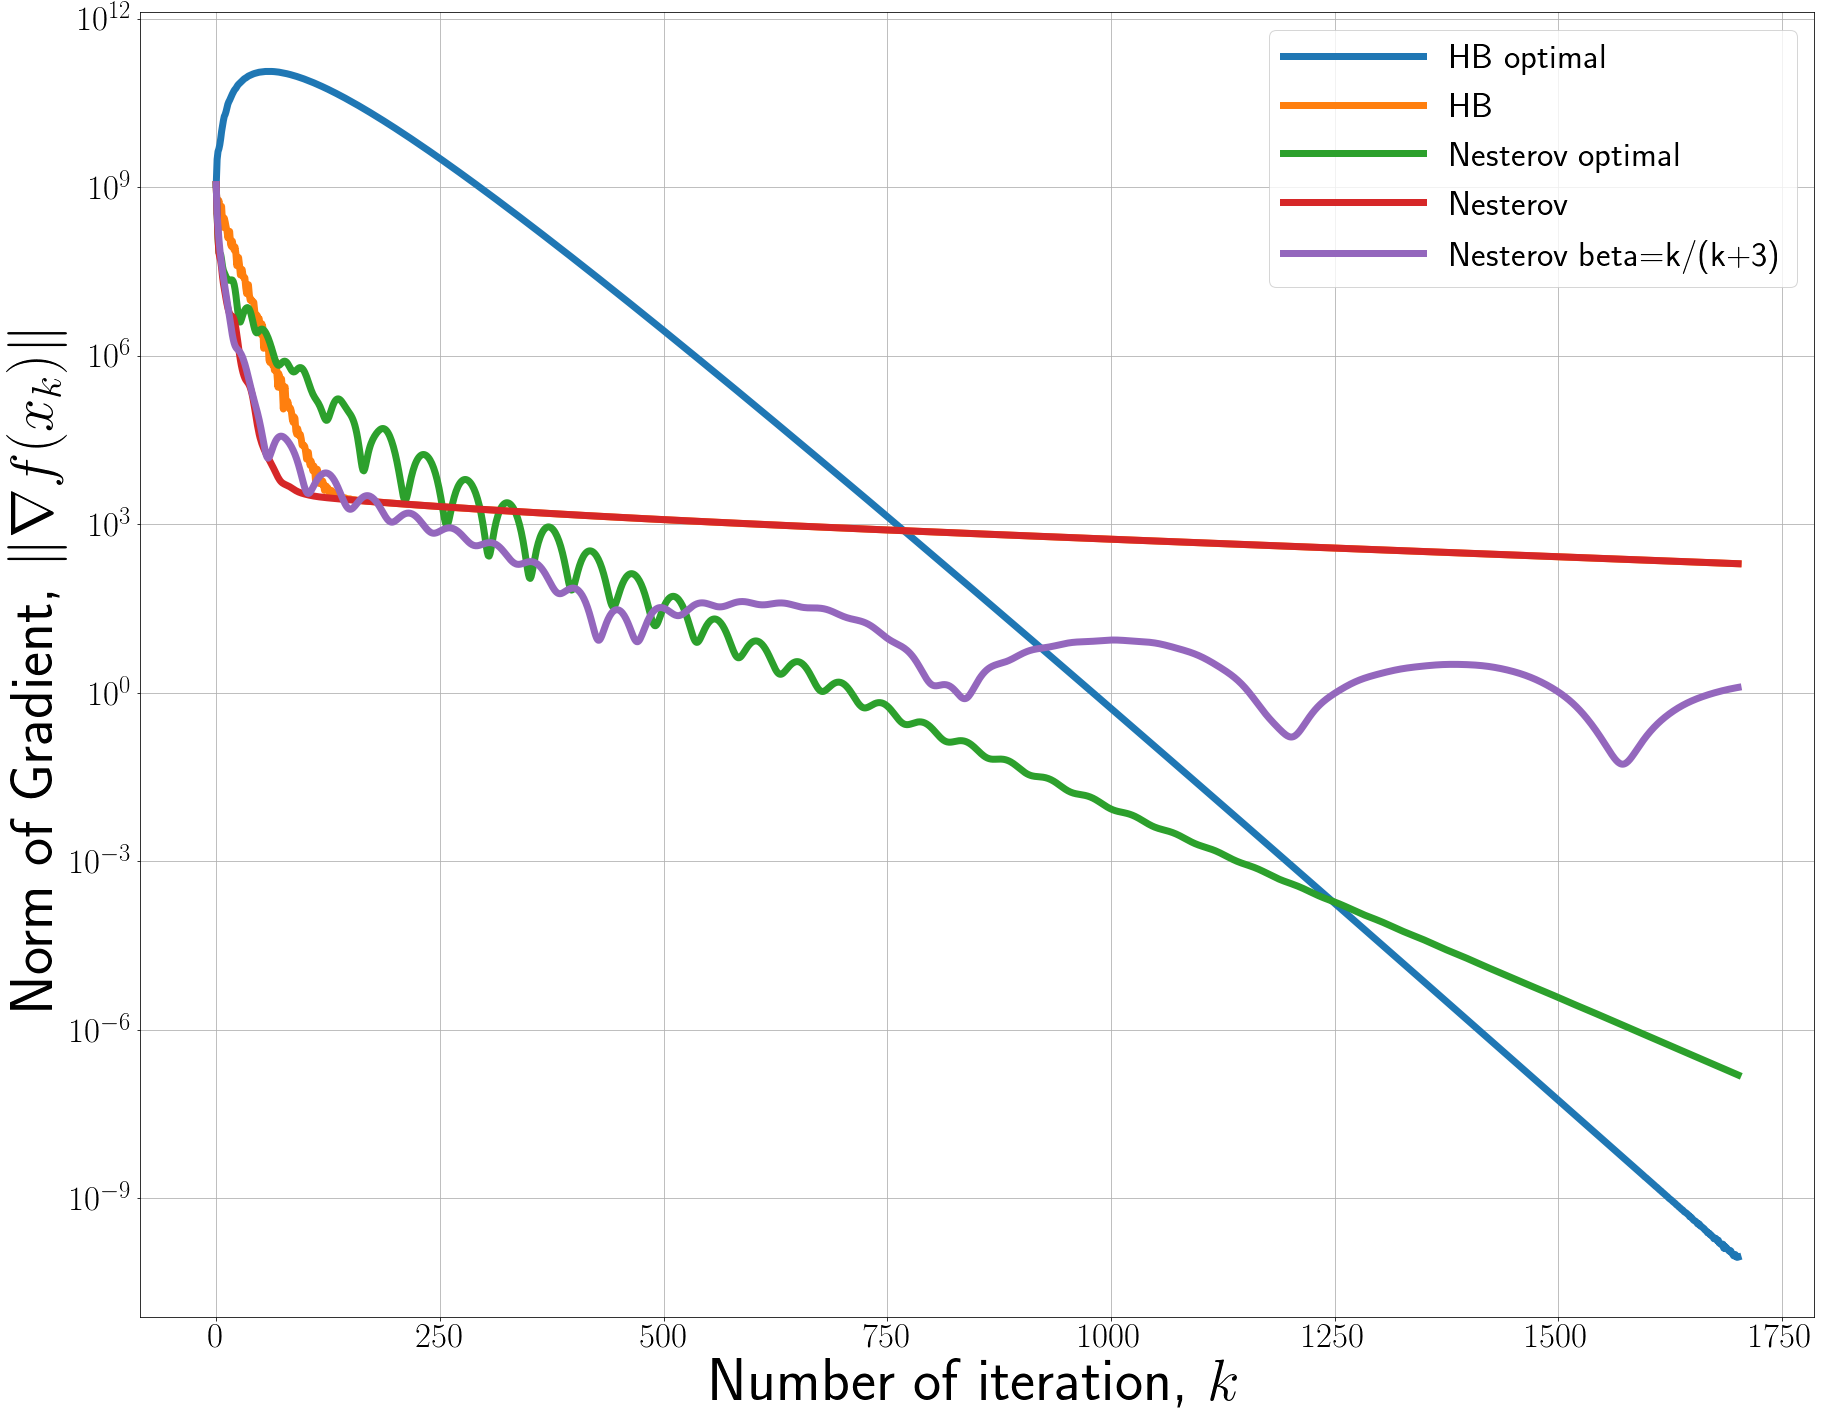

In [24]:
%matplotlib inline
plt.figure(figsize=(30, 24))
f_star = f(np.linalg.solve(A, -b))
funcx = lambda x: f(x) - f_star
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

### Restarts

\begin{equation*}
\begin{split}
& y_0 = x_0 \\
& x_{k+1} = y_k - \alpha_k f'(y_k)\\
& y_{k+1} = x_{k+1} + \beta_k(x_{k+1} - x_k)
\end{split}
\end{equation*}

RESTART for Iteration $K$: 

$y_K= x_K$

In [25]:
methods = [
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3)"),
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3),restart=10", restart=10),
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3),restart=50", restart=50),
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3),restart=100", restart=100),
           Nesterov(alpha=1/(L+mu), name="Nesterov beta=k/(k+3),restart=1000", restart=1000),
           Nesterov(alpha=1/(L+mu), L=L, mu=mu, name="Nesterov optimal"),
          ]

In [26]:
N = 3000
for method in methods:
    method.solve(x0, f, gradf, tol=1e-6, max_iter=N)

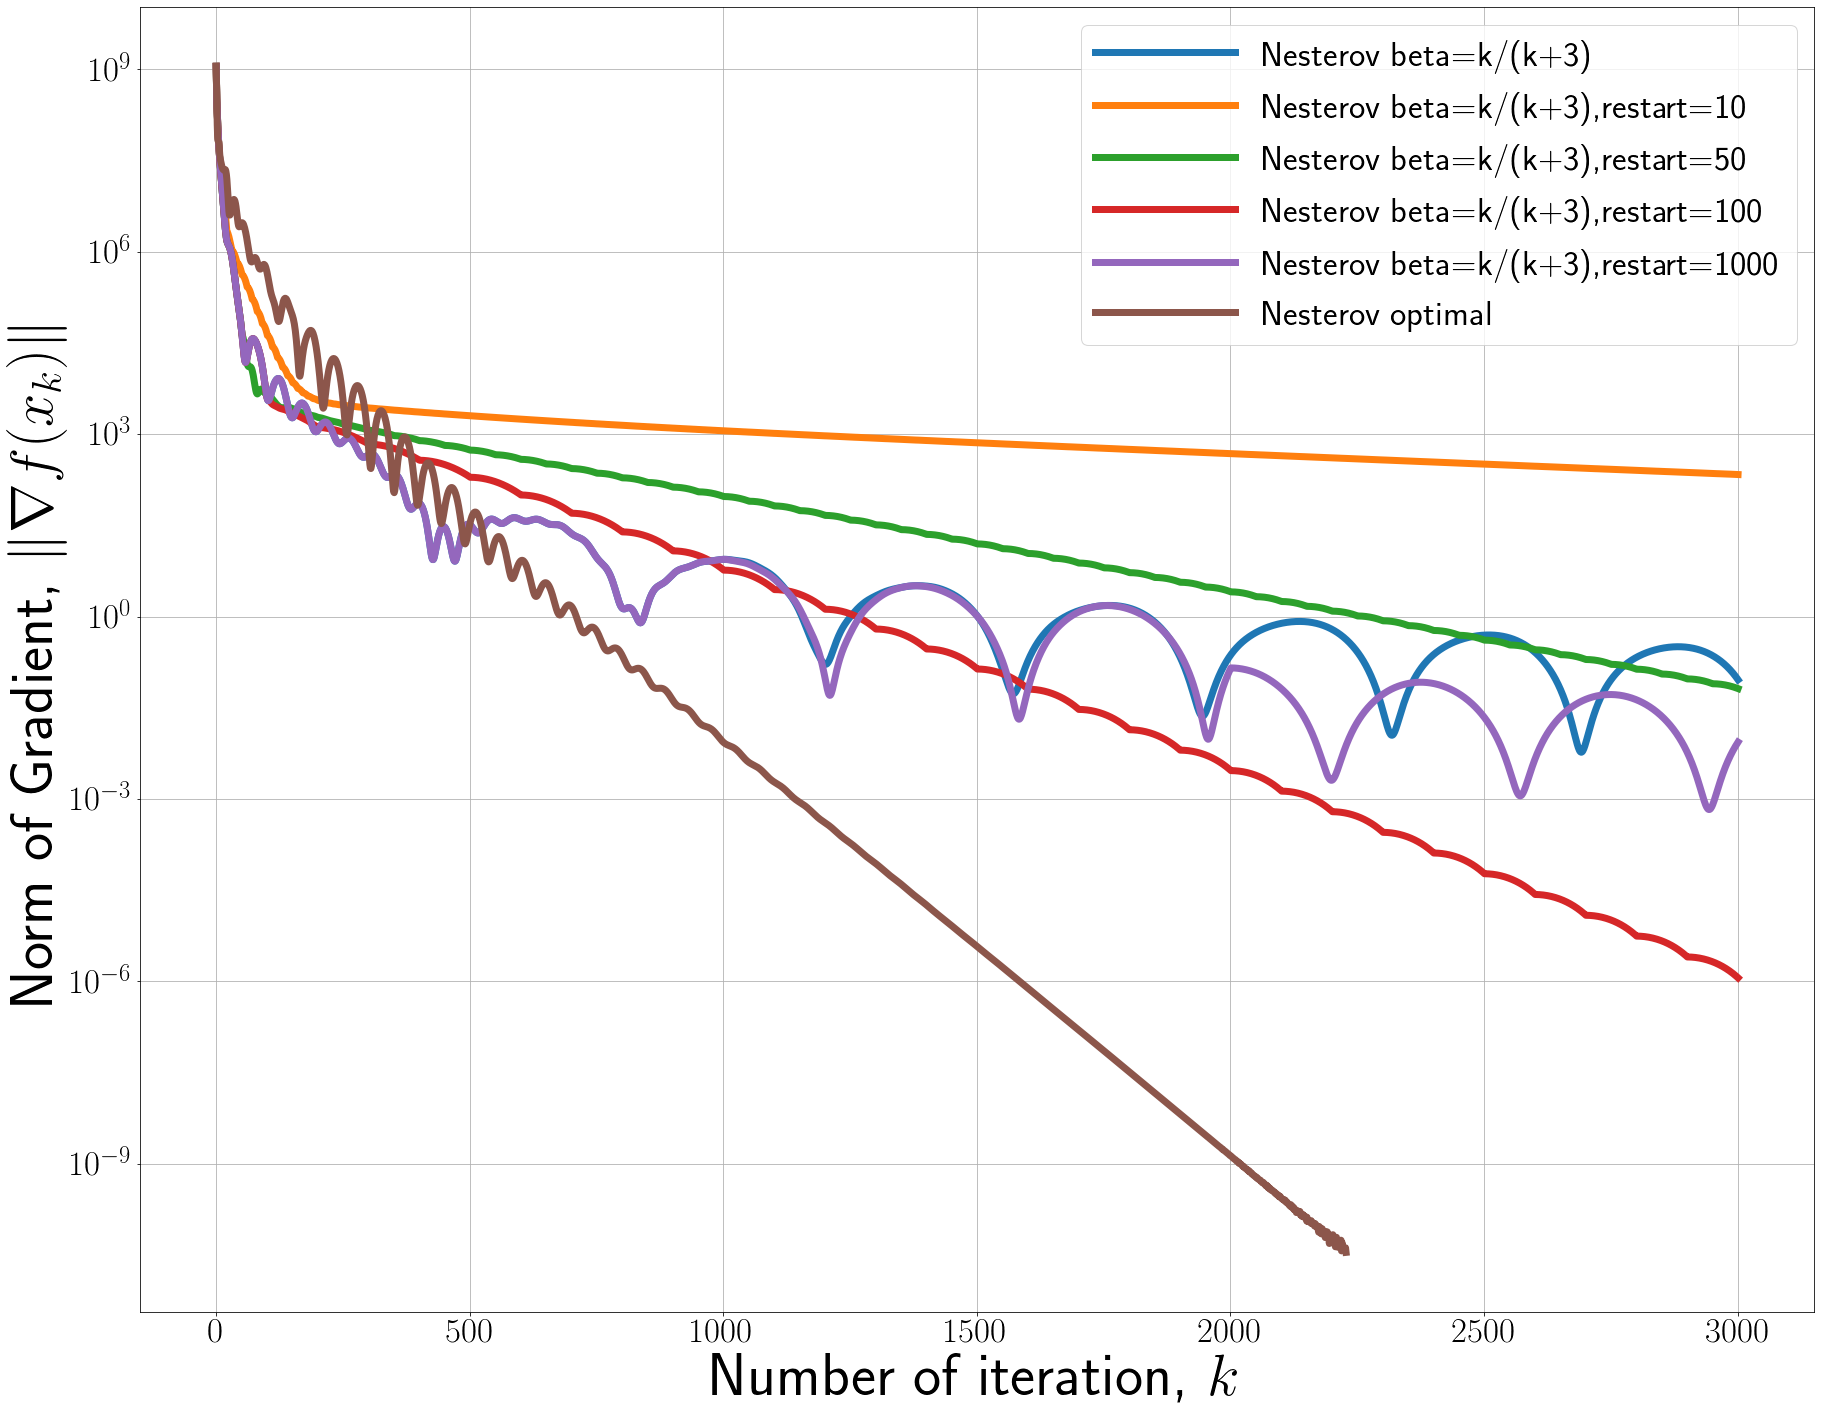

In [27]:
%matplotlib inline
plt.figure(figsize=(30, 24))
f_star = f(np.linalg.solve(A, -b))
funcx = lambda x: f(x) - f_star
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

* Метод Нестерова показывает осцилирующее поведение
* Ускоренные методы чувствительны к параметрам
* Рестарты могут позволить улучшить сходимость

## 3. Методы сопряженных градиентов

### 3.1. Система линейных уравнений vs. задача безусловной минимизации
Рассмотрим задачу
$$
\min_{x \in \mathbb{R}^n} \frac{1}{2}x^{\top}Ax - b^{\top}x,
$$
где $A \in \mathbb{S}^n_{++}$.
Из необходимого условия экстремума имеем
$$
Ax^* = b
$$
Также обозначим $f'(x_k) = Ax_k - b = r_k$

С другой стороны, если у нас есть СЛАУ:
$$Ax = b,$$
то эту задачу можно свести к задачи квадратичного программирования:

$$\|Ax-b\|^2\rightarrow \min_{x\in \mathbb{R}^n}$$

#### Как решить систему $Ax = b$?

- Прямые методы основаны на матричных разложениях:
    - Плотная матрица $A$: для размерностей не больше нескольких тысяч
    - Разреженная (sparse) матрица $A$: для размерностей порядка $10^4 - 10^5$
- Итерационные методы: хороши во многих случаях, единственный подход для задач с размерностью $ > 10^6$

### 3.2. Метод сопряжённых направлений

В градиентном спуске направления убывания - анти-градиенты, но для функций с плохо обусловленным гессианом сходимость **медленная**.

**Идея:** двигаться вдоль направлений, которые гарантируют сходимость за $n$ шагов.

**Определение.** Множество ненулевых векторов $\{p_0, \ldots, p_l\}$ называется *сопряжённым* относительно матрицы $A \in \mathbb{S}^n_{++}$, если 
$$
p^{\top}_iAp_j = 0, \qquad i \neq j
$$

**Пример**: собственные векторы матрицы $A$

$p_i$ - с.в. матрицы $A$

$Ap_i = \lambda_i p_i$

$p_i^\top p_j = 0, i\neq j$

$p_i^\top Ap_j = \lambda_j p_i^\top p_j = 0$

**Утверждение.** Для любой $x_0 \in \mathbb{R}^n$ последовательность $\{x_k\}$, генерируемая методом сопряжённых направлений, сходится к решению системы $Ax = b$ максимум за $n$ шагов.

```python
def ConjugateDirections(x0, A, b, p):
    x = x0
    r = A.dot(x) - b
    for i in xrange(len(p)):
        alpha = - (r.dot(p[i])) / (p[i].dot(A.dot(p[i])))
        x = x + alpha * p[i]
        r = A.dot(x) - b
    return x
```

$p_0 = -r_0 = -\nabla f(x_0)= -(Ax_0+b)$

$p_k = -r_k + \beta_k p_{k-1}$

$\beta_k: p_{k-1}^\top Ap_k=0$

$p_{k-1}^\top A(-r_k + \beta_k p_{k-1})=0$

### 3.3. Метод сопряжённых градиентов для квадратичной функции

**Идея:** новое направление $p_k$ ищется в виде $p_k = -r_k + \beta_k p_{k-1}$, где $\beta_k$ выбирается, исходя из требования сопряжённости $p_k$ и $p_{k-1}$:

$$0=p_{k-1}^\top A p_k =p_{k-1}^\top A( -r_k + \beta_k p_{k-1})$$

$$
\beta_k = \dfrac{p^{\top}_{k-1}Ar_k}{p^{\top}_{k-1}Ap_{k-1}}=\dfrac{\|r_k\|_2^2}{\|r_{k-1}\|_2^2}
$$
Таким образом, для получения следующего сопряжённого направления $p_k$ необходимо хранить только сопряжённое направление $p_{k-1}$ и остаток $r_k$ с предыдущей итерации. 

$$\alpha_k = \arg\min\left(f(x_k + \alpha_k p_k)\right)$$

$$\alpha_k = -\frac{r_k^\top p_k}{p_k^\top A p_k}=-\frac{\|r_k\|^2_2}{p_k^\top A p_k}$$

#### Теоремы сходимости

**Теорема 1.** Если матрица $A$ имеет только $r$ различных собственных значений, то метод сопряжённых градиентов cойдётся за $r$ итераций.

**Теорема 2.** Имеет место следующая оценка сходимости
$$
\| x_{k+1} - x^* \|_A \leq \left( \dfrac{\sqrt{\kappa(A)} - 1}{\sqrt{\kappa(A)} + 1} \right)^k \|x_0 - x^*\|_A,
$$
где $\|x\|_A = x^{\top}Ax$ и $\kappa(A) = \frac{\lambda_n(A)}{\lambda_1(A)}$ - число обусловленности матрицы $A$

### 3.4. Эксперименты на квадратичной функции

In [28]:
class ConjugateGradientQuadratic:
    def __init__(self, A, b, return_history=True, name=None):
        self.name = name
        self.A, self.b = A.astype(np.float64), b.astype(np.float64)
        self.return_history = return_history
        self.history = []

    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        A, b = self.A, self.b
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        r = gradf(x)
        p = -r
        while k == 0 or np.linalg.norm(gradf(x)) > tol: 
            alpha = r.dot(r) / p.dot(A.dot(p))
            x = x + alpha * p
            r_next = r + alpha * A.dot(p)
            beta = r_next.dot(r_next) / r.dot(r)
            p = -r_next + beta * p
            r = r_next
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

In [29]:
np.random.seed(1)
n = 50
A = np.random.randn(n, n)
A = A.T @ A 
b = np.random.randn(n)

n = 50
A = np.random.randn(n, n)
A = A.T.dot(A)
x_true = np.random.randn(n)
b = A.dot(x_true)
f = lambda x: 1/2 * x.T @ A @ x + b.T @ x
gradf = lambda x: A @ x + b
x0 = np.zeros(n)

In [30]:
A_eigvals = np.linalg.eigvalsh(A)
L = np.max(A_eigvals)
mu = np.min(A_eigvals)
L/mu, L, mu

(45190.05276715931, 177.24417304785158, 0.003922194425421409)

In [31]:
methods = [GradientDescent(ConstantStepSize(1 / L), name="GD, 1/L"),
           GradientDescent(Armijo(rho=1/2), name=r"GD, Armijo"),
           HeavyBall(L=L, mu=mu, name="HB optimal"),
           HeavyBall(alpha=0.005, beta=0.95, name="HB"),
           Nesterov(alpha=1/(L), name="Nesterov"),
           ConjugateGradientQuadratic(A, b, name="CG")
          ]

In [32]:
N = 5000
for method in methods:
    method.solve(x0, f, gradf, tol=1e-5, max_iter=N)

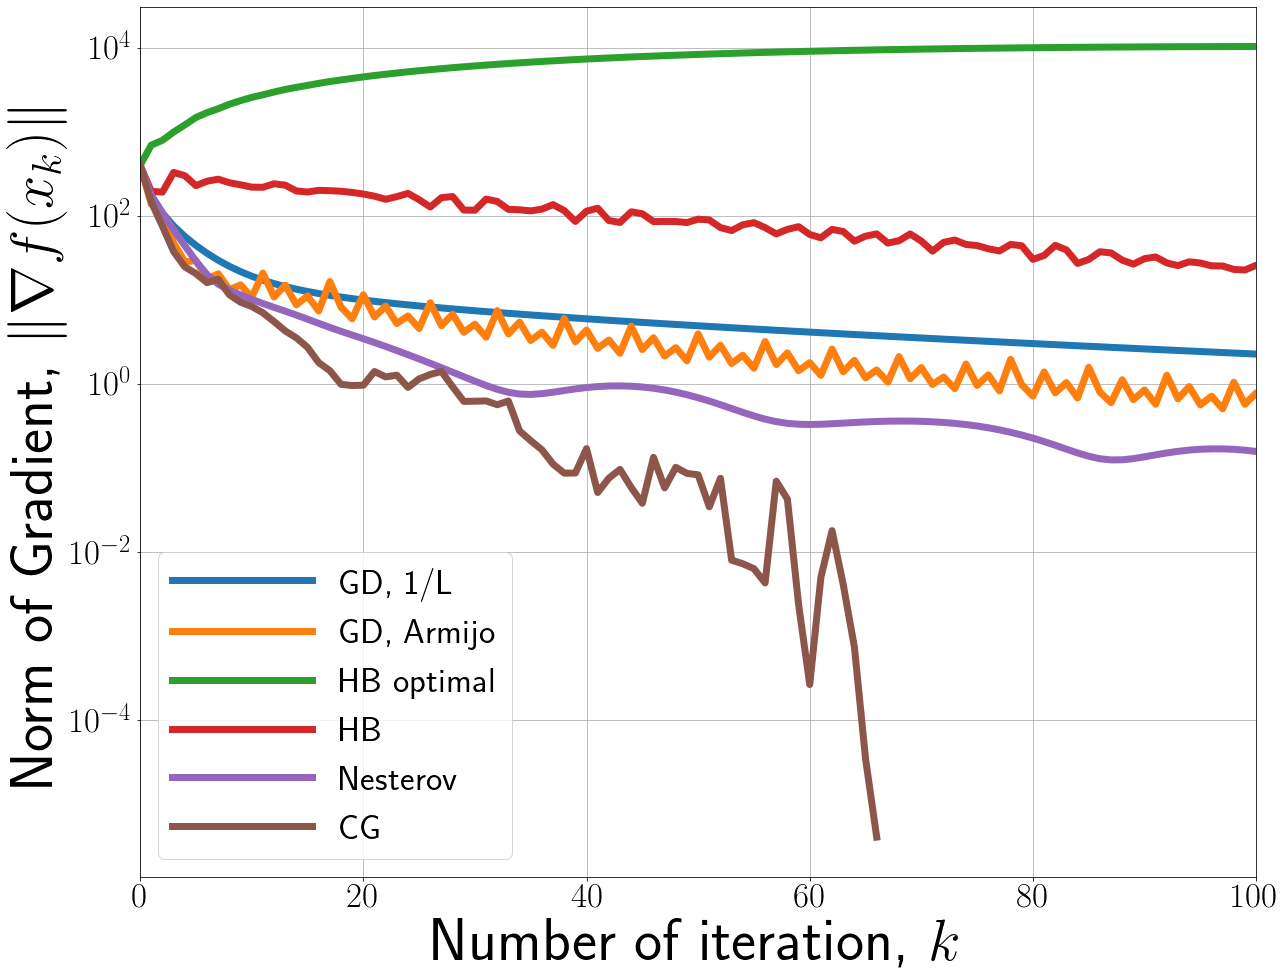

In [33]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.xlim(0, 100)
plt.legend()

### 3.5. Методы сопряжённых градиентов для неквадратичной функции

### 3.5.1. Метод Флетчера-Ривса
**Идея:** использовать градиенты $f'(x_k)$ неквадратичной функции вместо остатков $r_k$ и линейный поиск шага $\alpha_k$ вместо аналитического вычисления. Получим метод Флетчера-Ривса.

####  Теорема сходимости для метода Флетчера-Ривса

**Теорема.** Пусть 
- множество уровней $\mathcal{L}$ ограничено
- существует $\gamma > 0$: $\| f'(x) \|_2 \leq \gamma$ для $x \in \mathcal{L}$
Тогда
$$
\lim_{j \to \infty} \| f'(x_{k_j}) \|_2 = 0
$$

### 3.5.2.  Метод Полака-Рибьера

Для квадратичной задачи:
$$\beta_k = \dfrac{p^{\top}_{k-1}Ar_k}{p^{\top}_{k-1}Ap^{\top}_{k-1}} = \dfrac{(r_k - r_{k-1})r_k}{(-r_{k-1} + \beta_{k-1} p_{k-2})^\top (r_k - r_{k-1})} = \dfrac{\|r_k\|_2^2}{\|r_{k-1}\|_2^2},$$

$$\beta_{k} = \dfrac{\|r_k\|_2^2}{\|r_{k-1}\|_2^2} = \dfrac{(r_k - r_{k-1})^\top  r_k}{\|r_{k-1}\|_2^2}$$

Метод Полака-Рибьера:

$$\beta_{k} = \dfrac{\langle \nabla f(x_{k}) -\nabla f(x_{k-1}), \nabla f(x_{k})\rangle}{\|\nabla f(x_{k-1})\|^2_2}$$

In [34]:
class ConjugateGradients:
    def __init__(self, StepSizeChoice, restart=False, 
                 beta_strategy="FR",
                 return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.restart = restart
        self.history = []
        self.beta_strategy = beta_strategy
    
    def get_beta(self, grad_next, grad):
        if self.beta_strategy == "FR":
            return grad_next.dot(grad_next) / grad.dot(grad)
        elif self.beta_strategy == "PR":
            return grad_next.dot(grad_next-grad) / grad.dot(grad)
        else:
            raise Exception("Not implemented error")
    
    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        grad = gradf(x)
        p = -grad
        while k == 0 or np.linalg.norm(gradf(x)) > tol: 
            alpha = self.StepSizeChoice(x, p, k, gradf, f)
            if alpha < 1e-18:
                break
            x = x + alpha * p
            grad_next = gradf(x)
            beta = self.get_beta(grad_next, grad)
            p = -grad_next + beta * p
            grad = grad_next.copy()
            k += 1
            if self.restart and k % self.restart == 0:
                grad = gradf(x)
                p = -grad
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
        return x

### Перезапуск (restart)

1. Для ускорения метода сопряжённых градиентов используют технику перезапусков: удаление ранее накопленной истории и перезапуск метода с текущей точки, как будто это точка $x_0$
2. Существуют разные условия, сигнализирующие о том, что надо делать перезапуск, например
    - $k = n$
    - $\dfrac{|\langle f'(x_k), f'(x_{k-1}) \rangle |}{\| f'(x_k) \|_2^2} \geq \nu \approx 0.1$
3. Можно показать (см. Nocedal, Wright Numerical Optimization, Ch. 5, p. 125), что запуск метода Флетчера-Ривза без использования перезапусков на некоторых итерациях может приводить к крайне медленной сходимости! 
4. Метод Полака-Рибьера и его модификации лишены подобного недостатка.

### 3.6. Эксперименты на неквадратичной функции


Рассмотрим задачу логистической регрессии:

$$\min_{w\in\mathbb{R}^n} \frac{1}{m} \sum\limits_{i=1}^m \log\left(1+\exp(-y_i \langle w, x_i\rangle)\right) + \frac{\lambda}{2}\|w\|_2^2,$$
где $\{x_i, y_i\}_{i=1}^m \in \mathbb{R}^n\times \{-1,1\}$ есть обучающая выборка, $\lambda\in\mathbb{R}_+$ - некоторый параметр $\ell_2$-регуляризации.

In [35]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

/home/elias/anaconda3/lib/python3.7/site-packages/pandas/compat/_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [40]:
X = mnist.data.to_numpy()
x0 = 10 * np.ones(X.shape[-1])
y = mnist.target.to_numpy().astype(int)
print(y)
mask = (y == 0) + (y == 1)
X = (X[mask] - X.mean(axis=0)) / (1e-9+X.std(axis=0))
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
x0 = 10 * np.ones(X.shape[-1])
y = (y[mask] - 1/2)*2
labda = 1e-4

[5 0 4 ... 4 5 6]


In [41]:
@jax.jit
def f(w):
    v = -y * (X @ w)
    u_plus = jnp.maximum(v, 0)
    u_min = jnp.minimum(v, 0)
    res = (u_plus + jnp.log(jnp.exp(-u_plus) + jnp.exp(u_min))).mean()
    reg = labda/2 * (w**2).sum()
    return res + reg

gradf = jax.jit(jax.grad(f, argnums=0))
# np.linalg.norm(gradf(x0))

In [42]:
methods = [GradientDescent(Wolfe(beta1=0.1, beta2=0.4), name="GD, Wolfe"),           
           HeavyBall(alpha=100, beta=0.8, name="HB"),
           Nesterov(alpha=100, beta=0.8, name="Nesterov"),
          ]

for beta_strategy in ["FR", "PR"]:
    for restart in [None, 10, 100]:
        method = ConjugateGradients(Wolfe(), restart=restart, 
                                    beta_strategy=beta_strategy,
                                    name=f"CG {beta_strategy}, restart={restart}")
        methods.append(method)

In [43]:
N = 1000
for method in methods:
    print(method.name)
    x = method.solve(x0, f, gradf, tol=1e-6, max_iter=N)
    print(np.linalg.norm(gradf(x)))

GD, Wolfe
8.64085637667057e-07
HB
9.643236890366144e-07
Nesterov
9.349724035958873e-07
CG FR, restart=None
0.004800937419125227
CG FR, restart=10
9.955589903717036e-07
CG FR, restart=100
9.489027503033849e-07
CG PR, restart=None
9.597574888160176e-07
CG PR, restart=10
9.7535403260271e-07
CG PR, restart=100
9.819569222947042e-07


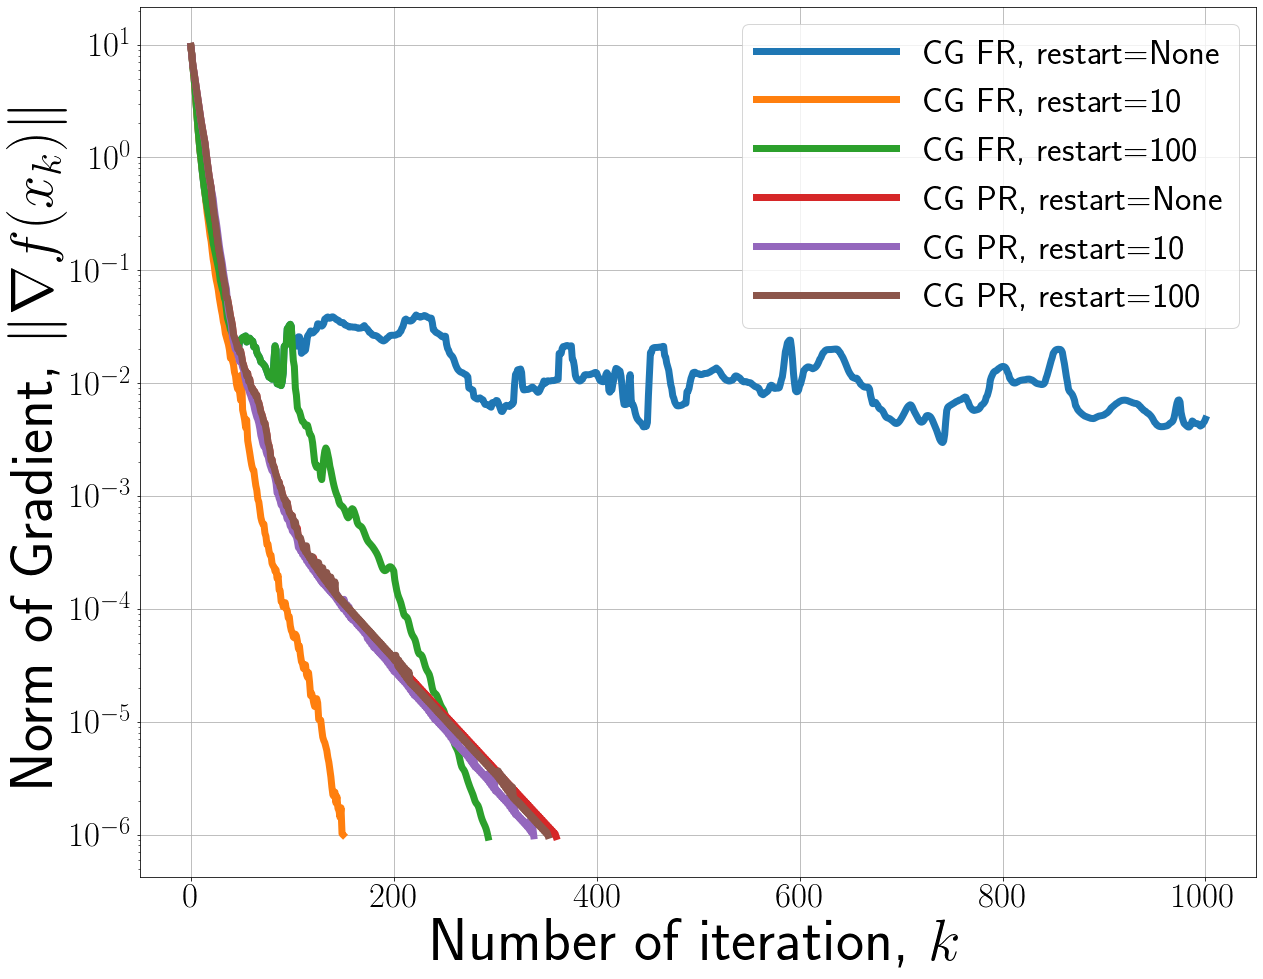

In [44]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    if "CG" in method.name:
        xhistory = method.history
        times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
        plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

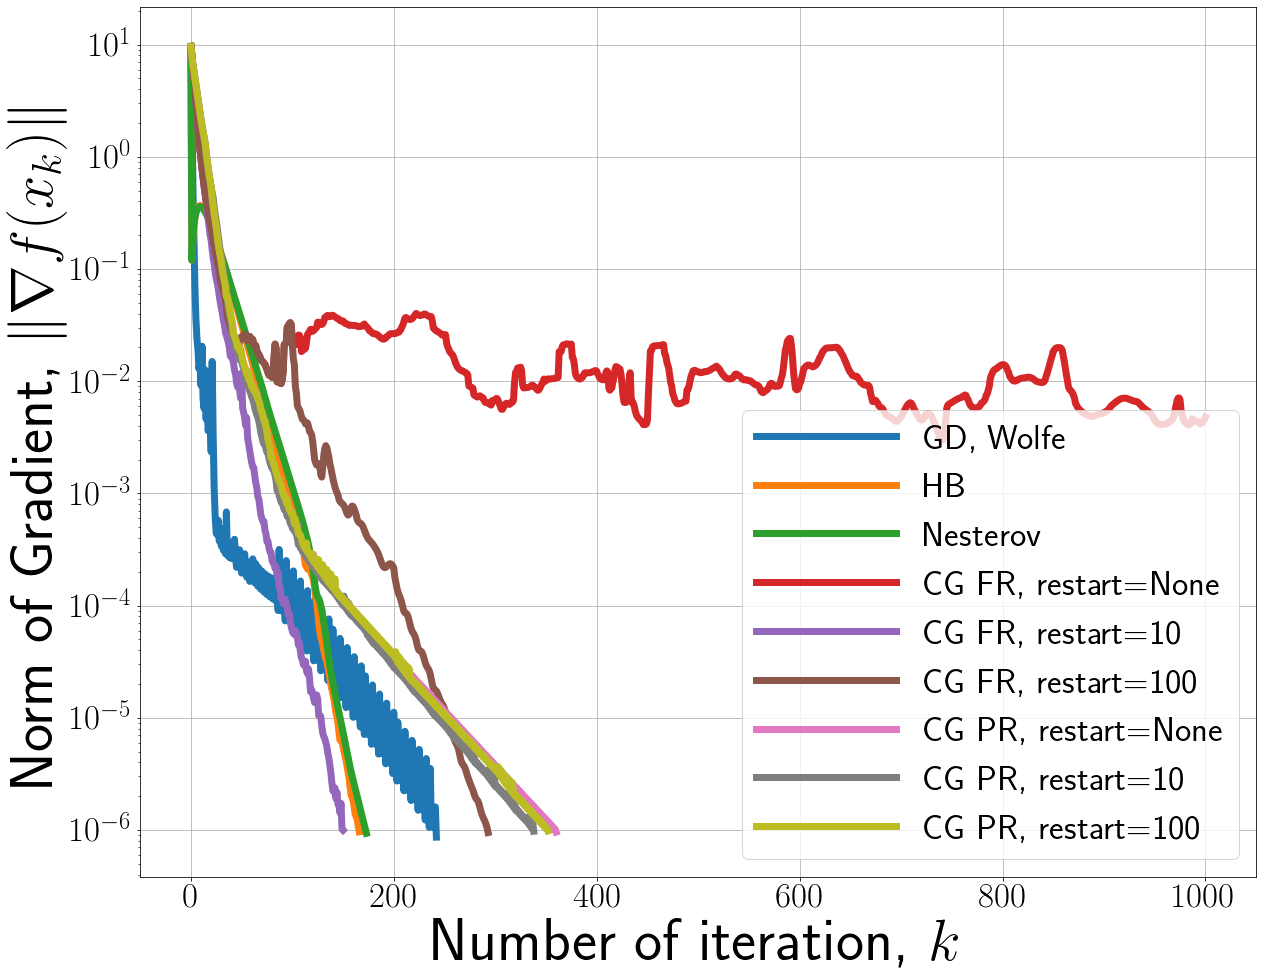

In [45]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

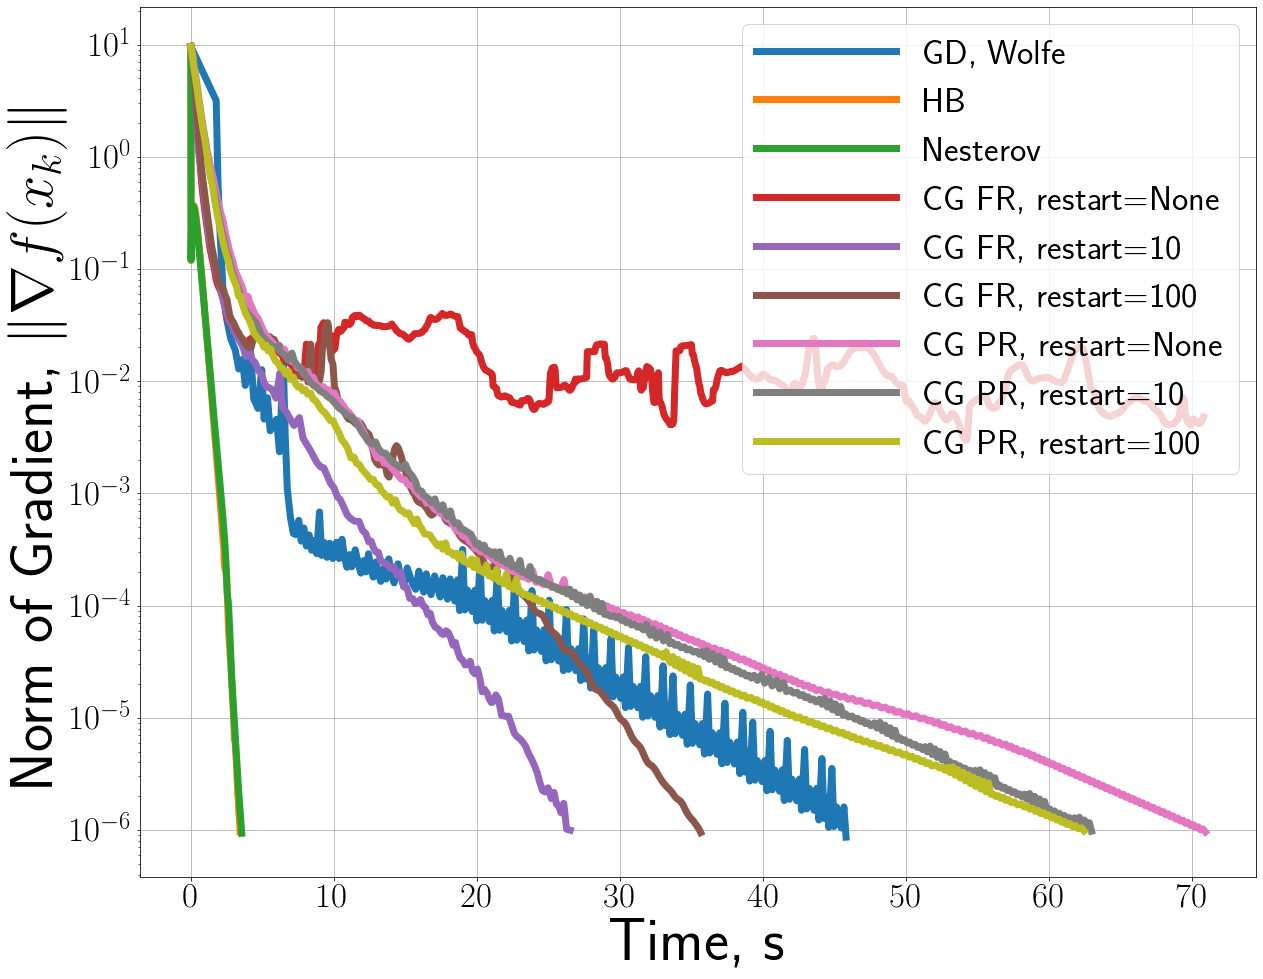

In [46]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=True, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Time, s")
plt.legend()

## Резюме

1. Метод тяжелого шарика и метод Нестерова требовательны к настройке параметров $\alpha_k, \beta_k$

2. Метод Нестерова является оптимальным в теории для правильно подобранных параметров

3. Техника рестартов может помочь ускорить методы

4. Направления в методах сопряженных градиентов для квадратичных задач будут являться направлением убывания, если шаг подбирается через усиленное условие Вольфа

5. Метод Флетчера-Ривса требует настройки рестартов

6. Метод Полака-Рибьера показывает хорошую скорость сходимости и без рестартов